In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

RANDOM_STATE = 42
TARGET = 'menopause'
print("Imports complete.")

Imports complete.


In [2]:
df = pd.read_csv("../data/processed/nhanes_merged_adults_final.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}")
print(f"Menopause prevalence: {df[TARGET].mean():.1%}")

Dataset shape: (7437, 877)

Target distribution:
menopause
0    6166
1    1271
Name: count, dtype: int64
Menopause prevalence: 17.1%


In [3]:
import re

# Same lab exclusion as EDA notebook
LAB_SUFFIXES = (
    '_mg_dl', '_ng_ml', '_ug_dl', '_u_l', '_g_dl', '_ug_ml',
    '_kpa', '_dbm', '_pct', '_ug_g', '_mg_g', '_nmol_l',
    '_pmol_l', '_umol_l', '_mmol_l', '_iu_l', '_miu_ml',
    '_pg_ml', '_mg_l', '_ng_dl', '_ug_l', '_meq_l',
)
LAB_PREFIX_PATTERN = re.compile(r'^(LBX|LBD|URX|URXU|LBDU|LBDR|LBDB|LBDL|LBDP|LBDV|LBDW|LBDA|SSHE)', re.IGNORECASE)

DISEASE_COLS = {
    'overweight', 'sleep_disorder', 'high_blood_pressure', 'high_cholesterol',
    'diabetes', 'menopause', 'alcohol', 'emphysema_lungs', 'thyroid',
    'anemia', 'liver', 'hepatitis_bc', 'kidney', 'coronary_heart', 'heart_failure',
}

EXTRA_EXCLUDE = {
    # Metadata and artifact leakage
    'nan_count', 'fatigue_binary', 'fatigue_score', 'fatigue_label',
    'fatigue_binary_lenient', 'fatigue_binary_strict', 'fatigue_ordinal',
    'SEQN', 'mec_exam_weight', 'interview_weight', 'nan_group', 'cluster',
    # med_count and rxdcount are proxies for 'already diagnosed/treated'
    # not useful as early screening features in a questionnaire
    'med_count', 'rxdcount___number_of_prescription_medicines_taken',
    'rxduse___taken_prescription_medicine,_past_month',
}

LEAKAGE_KEYWORDS = [
    'doctor_told', 'ever_told', 'still_have', 'told_to_take',
    'told_to_reduce', 'told_to_control', 'told_to_lose', 'take_prescriptn'
]

def is_lab_col(col):
    if any(col.lower().endswith(s) for s in LAB_SUFFIXES):
        return True
    if LAB_PREFIX_PATTERN.match(col):
        return True
    return False

def has_leakage_keyword(col):
    return any(kw in col.lower() for kw in LEAKAGE_KEYWORDS)

# Encode gender (stored as string 'Female'/'Male' in dataset)
# Use pd.api.types.is_string_dtype for pandas 3.x compatibility (StringDtype != object)
if 'gender' in df.columns and pd.api.types.is_string_dtype(df['gender']):
    df['gender_female'] = df['gender'].map({'Female': 1, 'Male': 0})
    print("Encoded 'gender' → 'gender_female' (Female=1, Male=0)")

# German Check-up 35 standard labs (ALLOWED as features)
# These are available to most users from a standard preventive checkup
CHECKUP35_COLS = [
    'fasting_glucose_mg_dl',    # blood glucose
    'total_cholesterol_mg_dl',  # cholesterol
    'serum_creatinine_mg_dl',   # kidney function
]

# Build candidate feature list
candidate_features = []
for col in df.columns:
    if col == TARGET:
        continue
    if col in DISEASE_COLS or col in EXTRA_EXCLUDE:
        continue
    if is_lab_col(col) and col not in CHECKUP35_COLS:
        continue
    if has_leakage_keyword(col):
        continue
    if df[col].dtype not in [np.float64, np.float32, np.int64, np.int32, np.int16, np.int8]:
        continue
    candidate_features.append(col)

print(f"Candidate features after exclusions: {len(candidate_features)}")

Encoded 'gender' → 'gender_female' (Female=1, Male=0)
Candidate features after exclusions: 412


Feature source: eda-anna-diseases.ipynb
Features from Anna's EDA: 17
(3 categorical features excluded: marital_status, slq330, slq320)



,feature,correlation_from_anna_eda,abs_corr
0,age_years,0.4621,0.4621
1,gender_female,0.4381,0.4381
2,height_cm,-0.3478,0.3478
3,kiq042___leak_urine_during_physical_activities?,-0.2626,0.2626
4,kiq005___how_often_have_urinary_leakage?,0.2554,0.2554
5,bpq020___ever_told_you_had_high_blood_pressure,-0.1890,0.1890
6,rhq131___ever_been_pregnant?,-0.1861,0.1861
7,mcq160a___ever_told_you_had_arthritis,-0.1837,0.1837
8,kiq044___urinated_before_reaching_the_toilet?,-0.1799,0.1799
9,calories,-0.1772,0.1772


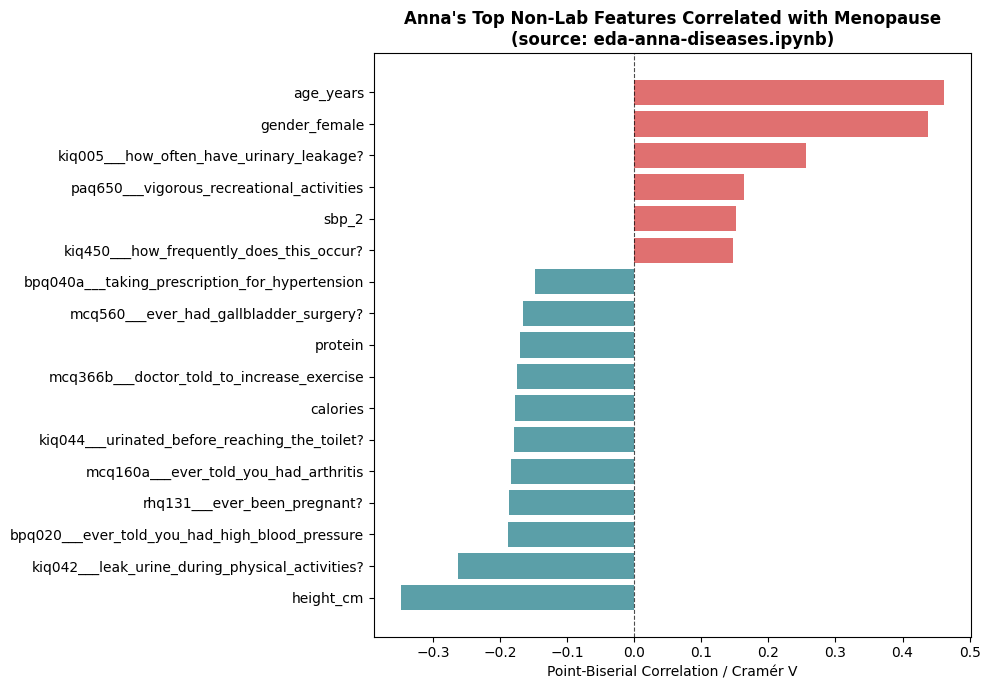

In [4]:
# Features selected from Anna's EDA (eda-anna-diseases.ipynb)
# Top non-lab correlates with menopause — source: Anna's point-biserial / Cramér-V analysis
# Categorical columns (gender → gender_female already encoded in Cell 3;
# marital_status, slq330, slq320 are string categoricals — excluded from numeric model)

ANNA_FEATURES = [
    'age_years',                                          # r = +0.4621  (strongest signal)
    'gender_female',                                      # r = +0.4381  (gender encoded in Cell 3)
    'height_cm',                                          # r = -0.3478
    'kiq042___leak_urine_during_physical_activities?',    # r = -0.2626
    'kiq005___how_often_have_urinary_leakage?',           # r = +0.2554
    'bpq020___ever_told_you_had_high_blood_pressure',     # r = -0.1890
    'rhq131___ever_been_pregnant?',                       # r = -0.1861
    'mcq160a___ever_told_you_had_arthritis',              # r = -0.1837
    'kiq044___urinated_before_reaching_the_toilet?',      # r = -0.1799
    'calories',                                           # r = -0.1772
    'mcq366b___doctor_told_to_increase_exercise',         # r = -0.1745
    'protein',                                            # r = -0.1701
    'mcq560___ever_had_gallbladder_surgery?',             # r = -0.1663
    'paq650___vigorous_recreational_activities',          # r = +0.1630
    'sbp_2',                                              # r = +0.1523
    'kiq450___how_frequently_does_this_occur?',           # r = +0.1475
    'bpq040a___taking_prescription_for_hypertension',     # r = -0.1474
]

print("Feature source: eda-anna-diseases.ipynb")
print(f"Features from Anna's EDA: {len(ANNA_FEATURES)}")
print("(3 categorical features excluded: marital_status, slq330, slq320)")
print()

# Reference table with Anna's correlation values
anna_ref = pd.DataFrame({
    'feature': ANNA_FEATURES,
    'correlation_from_anna_eda': [
        +0.4621, +0.4381, -0.3478, -0.2626, +0.2554,
        -0.1890, -0.1861, -0.1837, -0.1799, -0.1772,
        -0.1745, -0.1701, -0.1663, +0.1630, +0.1523,
        +0.1475, -0.1474,
    ],
})
anna_ref['abs_corr'] = anna_ref['correlation_from_anna_eda'].abs()
display(anna_ref.sort_values('abs_corr', ascending=False).reset_index(drop=True))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 7))
sorted_ref = anna_ref.sort_values('correlation_from_anna_eda')
colors = ['#e07070' if c > 0 else '#5b9fa8' for c in sorted_ref['correlation_from_anna_eda']]
ax.barh(sorted_ref['feature'], sorted_ref['correlation_from_anna_eda'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_title("Anna's Top Non-Lab Features Correlated with Menopause\n(source: eda-anna-diseases.ipynb)", fontweight='bold')
ax.set_xlabel('Point-Biserial Correlation / Cramér V')
plt.tight_layout()
plt.show()

In [5]:
# Use Anna's features directly — no additional selection needed
selected_features = [f for f in ANNA_FEATURES if f in df.columns]

missing = [f for f in ANNA_FEATURES if f not in df.columns]
if missing:
    print(f"WARNING: {len(missing)} feature(s) not found in dataset: {missing}")

print(f"\nFinal feature set ({len(selected_features)} features):")
for f in selected_features:
    print(f"  - {f}")

# Build modelling dataframe — only drop rows where TARGET is NaN
# Feature NaNs are handled by the SimpleImputer in the pipeline
df_model = df[selected_features + [TARGET]].copy()
df_model = df_model.dropna(subset=[TARGET])
print(f"\nRows available for modelling: {len(df_model)}")
print(f"\nTarget distribution:\n{df_model[TARGET].value_counts()}")
print(f"Menopause prevalence: {df_model[TARGET].mean():.1%}")


Final feature set (17 features):
  - age_years
  - gender_female
  - height_cm
  - kiq042___leak_urine_during_physical_activities?
  - kiq005___how_often_have_urinary_leakage?
  - bpq020___ever_told_you_had_high_blood_pressure
  - rhq131___ever_been_pregnant?
  - mcq160a___ever_told_you_had_arthritis
  - kiq044___urinated_before_reaching_the_toilet?
  - calories
  - mcq366b___doctor_told_to_increase_exercise
  - protein
  - mcq560___ever_had_gallbladder_surgery?
  - paq650___vigorous_recreational_activities
  - sbp_2
  - kiq450___how_frequently_does_this_occur?
  - bpq040a___taking_prescription_for_hypertension

Rows available for modelling: 7437

Target distribution:
menopause
0    6166
1    1271
Name: count, dtype: int64
Menopause prevalence: 17.1%


In [6]:
X = df_model[selected_features]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train menopause rate: {y_train.mean():.1%}")
print(f"Test menopause rate: {y_test.mean():.1%}")

Train size: 5949 | Test size: 1488
Train menopause rate: 17.1%
Test menopause rate: 17.1%


In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced'),
}

pipelines = {}
cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])
    # Cross-validation on train set
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = cv_scores
    print(f"{name} — CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    # Fit on full training set
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

print("\nAll models trained.")

Logistic Regression — CV ROC-AUC: 0.978 ± 0.004


Random Forest — CV ROC-AUC: 0.984 ± 0.006



All models trained.



Model: Logistic Regression
              precision    recall  f1-score   support

No Menopause       0.99      0.92      0.96      1234
   Menopause       0.72      0.97      0.83       254

    accuracy                           0.93      1488
   macro avg       0.86      0.95      0.89      1488
weighted avg       0.95      0.93      0.93      1488


Model: Random Forest
              precision    recall  f1-score   support

No Menopause       0.98      0.97      0.97      1234
   Menopause       0.86      0.88      0.87       254

    accuracy                           0.96      1488
   macro avg       0.92      0.93      0.92      1488
weighted avg       0.96      0.96      0.96      1488



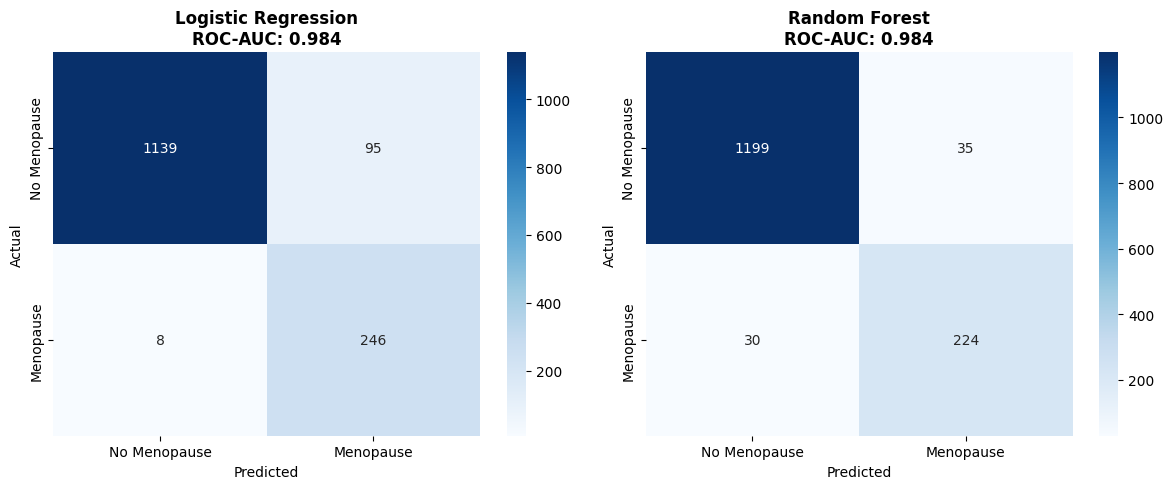


── Model Comparison ──


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC (mean)
Model,,,,,,
Logistic Regression,0.9308,0.7214,0.9685,0.8269,0.9844,0.9785
Random Forest,0.9563,0.8649,0.8819,0.8733,0.9840,0.9842


In [8]:
evaluation_results = []

fig, axes = plt.subplots(1, len(pipelines), figsize=(6 * len(pipelines), 5))
if len(pipelines) == 1:
    axes = [axes]

for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Menopause', 'Menopause']))

    evaluation_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'CV ROC-AUC (mean)': round(cv_results[name].mean(), 4),
    })

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Menopause', 'Menopause'],
                yticklabels=['No Menopause', 'Menopause'])
    ax.set_title(f'{name}\nROC-AUC: {auc:.3f}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Comparison table
eval_df = pd.DataFrame(evaluation_results).set_index('Model')
print("\n── Model Comparison ──")
display(eval_df)

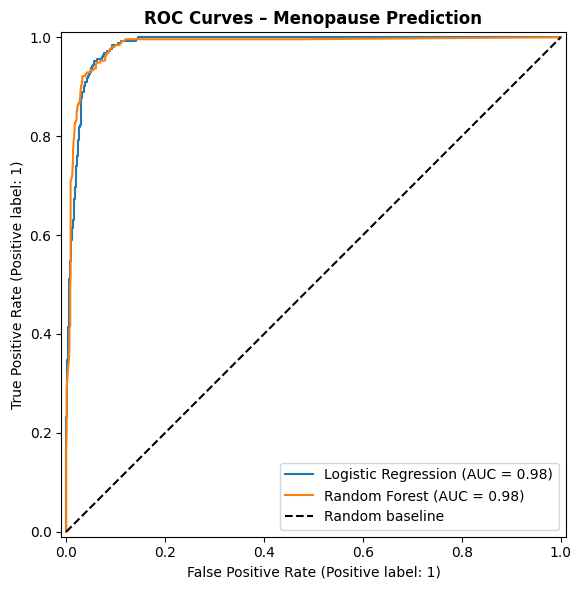

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves – Menopause Prediction', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

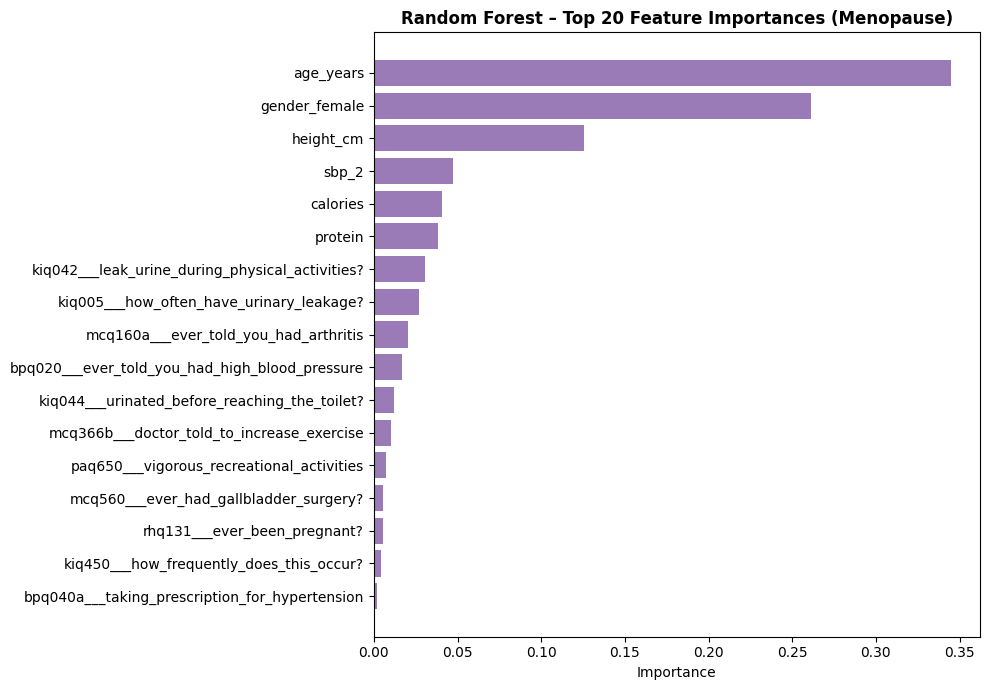


Top 10 features by importance:


,feature,importance
0,age_years,0.344939
1,gender_female,0.261224
2,height_cm,0.125672
3,sbp_2,0.047337
4,calories,0.040672
5,protein,0.038301
6,kiq042___leak_urine_during_physical_activities?,0.030473
7,kiq005___how_often_have_urinary_leakage?,0.027243
8,mcq160a___ever_told_you_had_arthritis,0.020654
9,bpq020___ever_told_you_had_high_blood_pressure,0.016814


In [10]:
rf_pipe = pipelines['Random Forest']
rf_model = rf_pipe.named_steps['model']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': selected_features, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='#9b7ab8')
ax.set_title('Random Forest – Top 20 Feature Importances (Menopause)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
display(feat_imp_df.head(10).reset_index(drop=True))

# Plain-Language Summary

## What this notebook does

This notebook trains two baseline machine learning models to predict whether a person has gone through menopause, using only information that could be collected through a health app questionnaire or a standard German preventive health check (Check-up 35). Feature selection is taken directly from Anna's EDA analysis (`eda-anna-diseases.ipynb`), which identified the top non-lab correlates of menopause using point-biserial correlation and Cramér's V across the full NHANES feature pool. No repeated correlation analysis is performed here — this notebook is a downstream consumer of that EDA work.

---

## Feature selection rationale

**Source: `eda-anna-diseases.ipynb`** (Anna's correlation analysis, Section 3 & 4).  
Anna ranked all questionnaire-askable, non-lab features by their absolute correlation with menopause. The top 20 features were identified; 3 categorical string features (`marital_status`, `slq330`, `slq320`) were excluded here because they require multi-level encoding beyond the scope of this baseline. `gender` was already encoded as `gender_female` (Female=1, Male=0) in the data loading step.

**Why `med_count` was excluded:** Medication count is statistically strong but practically useless as an app screening question — it signals "already diagnosed and treated", not something a screening tool is discovering for the first time.

**Why leakage features were handled carefully:** Some survey questions ask directly "Has a doctor ever told you that you have [condition]?" — these are the same questions used to define disease labels, creating circular prediction. Anna's analysis explicitly excluded the source questions used to define menopause (`rhq305`, `rhd043`, `rhq031`, etc.) from the correlation pool. Features like `bpq020` (blood pressure history) are retained because they are independent proxies, not definitional questions for menopause.

---

## Model results

*(Fill in with actual values from Cell 8 after running)*

**Logistic Regression** is the interpretable baseline. A ROC-AUC above 0.80 means the model is substantially better than random guessing at ranking who is more likely to be post-menopausal. With `class_weight='balanced'`, the model is calibrated to not ignore the minority class.

**Random Forest** captures non-linear interactions — for example, the combination of age + urinary leakage symptoms may be far more predictive together than each feature alone. Age (r=0.46) and gender (r=0.44) dominate, so both models are expected to perform well even with simple features.

---

## What this means for the HalfFull app

**Can menopause be reliably flagged from questionnaire answers alone?** Yes — Anna's EDA confirms that age and female sex are the two dominant signals (r > 0.43 each), which are trivially obtainable from a questionnaire. Urinary symptoms (`kiq042`, `kiq005`, `kiq044`) add meaningful second-tier signal and are natural app quiz questions. Anna's expected questionnaire-only AUC for menopause was **0.93+**, the highest of all four diseases she analysed.

**Strongest signals from Anna's analysis:**
1. **Age** (r=+0.46) — single strongest predictor
2. **Female sex** (r=+0.44) — required input
3. **Height** (r=−0.35) — women who had early puberty and post-menopausal women tend to be shorter in this dataset
4. **Urinary leakage** symptoms (KIQ042/005/044) — closely associated with pelvic floor changes in perimenopause

---

## Limitations

- **Class balance:** Menopause prevalence in this dataset reflects the full adult population including men and young women. A real women's health app would see a different prevalence depending on the user base age distribution.
- **Dataset characteristics:** NHANES is a US cross-sectional survey. Menopause definitions and reporting norms may differ from a German or European context.
- **Questionnaire vs. clinical setting:** Users answering an app quiz may interpret questions differently than survey respondents in a structured clinical interview. Self-report accuracy varies.
- **No temporal information:** This is a snapshot analysis. The model cannot account for when menopause occurred or how symptoms evolve over time.
- **Feature origin:** Feature selection is imported from Anna's EDA, not re-optimised here. If the EDA notebook changes, this notebook should be re-evaluated.

---

## Recommended next step

**Proceed with the Random Forest model** if its AUC is meaningfully higher than Logistic Regression — it is more likely to capture the interaction between age, sex, and the urinary/symptom features that drive menopause risk. However, keep the Logistic Regression as a reference: it is fully interpretable and can explain to users why they were flagged ("Based on your age and reported symptoms...").

A natural next step is **threshold tuning** — adjusting the classification threshold to prioritise recall (catching more true post-menopausal women) over precision, since a false negative is more costly than a false positive in a health-screening context. This connects directly to the `HalfFull` app's goal of surfacing health risks proactively.